In [1]:
import math
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage, HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Sequence, Literal

from IPython.display import Image, display


In [2]:
def mocked_google_search(query: str) -> str:
  print(f"CALLED GOOGLE_SEARCH with query={query}")
  return "Donald Trump is a president of USA and he's 78 years old"

def mocked_calculator(expression: str) -> float:
  print(f"CALLED CALCULATOR with expression={expression}")
  if "sqrt" in expression:
    return math.sqrt(78*132)
  return 78*132



calculator_tool = {
    "type": "function",
    "function": {
        "name": "calculator",
        "description": "Computes mathematical expressions",
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {
                    "type": "string",
                    "title": "expression",
                    "description": "A mathematical expression to be evaluated by a calculator"
                }
            },
            "required": ["expression"]
        }
    }
}

search_tool = {
    "type": "function",
    "function": {
        "name": "google_search",
        "description": "Returns about common facts, fresh events and news from Google Search engine based on a query.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "title": "search_query",
                    "description": "Search query to be sent to the search engine"
                }
            },
            "required": ["query"]
        }
    }
}


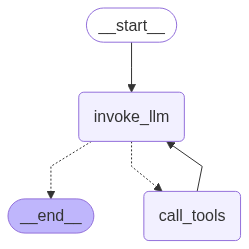

In [3]:
llm = ChatGoogleGenerativeAI(
     model='gemini-2.0-flash',
     temperature = 0
)


llm_with_tools = llm.bind(tools=[calculator_tool, search_tool])



class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


def invoke_llm(state: State):
   res = llm_with_tools.invoke(state["messages"])
   return {"messages":res}


def call_tools(state: State):

   last_message = state["messages"][-1]
   tool_calls = last_message.tool_calls

   new_messages = []

   for tool_call in tool_calls:
    if tool_call["name"] == "google_search":
        tool_result = mocked_google_search(**tool_call['args'])
        new_messages.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))

    elif tool_call["name"] == "calculator":
       tool_result =  mocked_calculator(**tool_call['args'])
       new_messages.append(ToolMessage(content=tool_result, tool_call_id=tool_call['id']))
    else:
       raise ValueError(f"Tool {tool_call['name']} is not defined!")

    return {"messages":new_messages}


def should_run_tools(state : State) -> Literal["call_tools", END]: # type: ignore
   last_message = state["messages"][-1]
   if last_message.tool_calls:
      return "call_tools"
   return END


builder = StateGraph(State)
builder.add_node("invoke_llm", invoke_llm)
builder.add_node("call_tools", call_tools)

builder.add_edge(START, "invoke_llm")
builder.add_conditional_edges("invoke_llm", should_run_tools)
builder.add_edge("call_tools", "invoke_llm")

graph = builder.compile()

image_data = graph.get_graph().draw_mermaid_png()
display(Image(data=image_data))

In [4]:
system_prompt = (
    "Always use a calculator for mathematical computations, and use Google Search "
    "for information about common facts, fresh events and news. Do not assume anything, keep in "
    "mind that things are changing and always "
    "check yourself with external sources if possible."
)

human_prompt = ("age of current US president")

message = [SystemMessage(content=system_prompt), HumanMessage(content=human_prompt)]
message

[SystemMessage(content='Always use a calculator for mathematical computations, and use Google Search for information about common facts, fresh events and news. Do not assume anything, keep in mind that things are changing and always check yourself with external sources if possible.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='age of current US president', additional_kwargs={}, response_metadata={})]

´message´ se deben promptear con alguna variable antes de invokarlos es el flujo del grafo.

In [21]:
message = ChatPromptTemplate.from_messages([
   ("system", system_prompt),
   ("human", human_prompt)
])
message

ChatPromptTemplate(input_variables=[], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='Always use a calculator for mathematical computations, and use Google Search for information about common facts, fresh events and news. Do not assume anything, keep in mind that things are changing and always check yourself with external sources if possible.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='age of current US president'), additional_kwargs={})])

In [5]:
initial_state = {"messages":message}
initial_state

{'messages': [SystemMessage(content='Always use a calculator for mathematical computations, and use Google Search for information about common facts, fresh events and news. Do not assume anything, keep in mind that things are changing and always check yourself with external sources if possible.', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='age of current US president', additional_kwargs={}, response_metadata={})]}

In [7]:
final_state = None
for event in graph.stream(initial_state, stream_mode="values"): #stream_mode="values"
    final_state = event
    for mensage in event["messages"]:
        #mensage.pretty_print()
        print(type(mensage))
        print(mensage)
        print()
    print('\n\n\n\n\n\n')
print(f"================================== Final State ==================================\n\n")
for mensage in final_state["messages"]:
    mensage.pretty_print()

<class 'langchain_core.messages.system.SystemMessage'>
content='Always use a calculator for mathematical computations, and use Google Search for information about common facts, fresh events and news. Do not assume anything, keep in mind that things are changing and always check yourself with external sources if possible.' additional_kwargs={} response_metadata={} id='6e3803d4-466c-4cfb-af80-c4a19defc2f9'

<class 'langchain_core.messages.human.HumanMessage'>
content='age of current US president' additional_kwargs={} response_metadata={} id='f389ea45-f147-46db-978c-0bb0e3035dda'








<class 'langchain_core.messages.system.SystemMessage'>
content='Always use a calculator for mathematical computations, and use Google Search for information about common facts, fresh events and news. Do not assume anything, keep in mind that things are changing and always check yourself with external sources if possible.' additional_kwargs={} response_metadata={} id='6e3803d4-466c-4cfb-af80-c4a19defc2f9'
